Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dimensiones: (257709, 27)
DIABETE3
3.0    0.889833
1.0    0.110167
Name: proportion, dtype: float64


/tmp/ipython-input-3338141962.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="DIABETE3", palette="Set2")


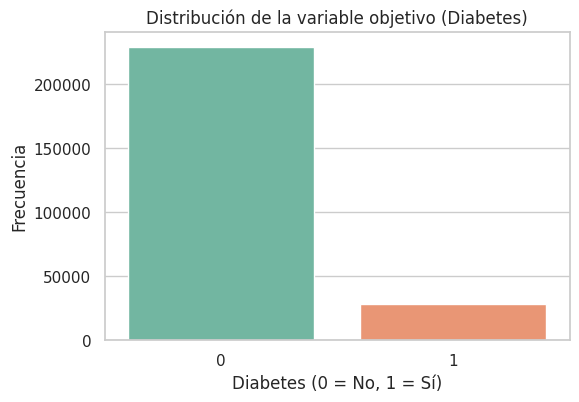

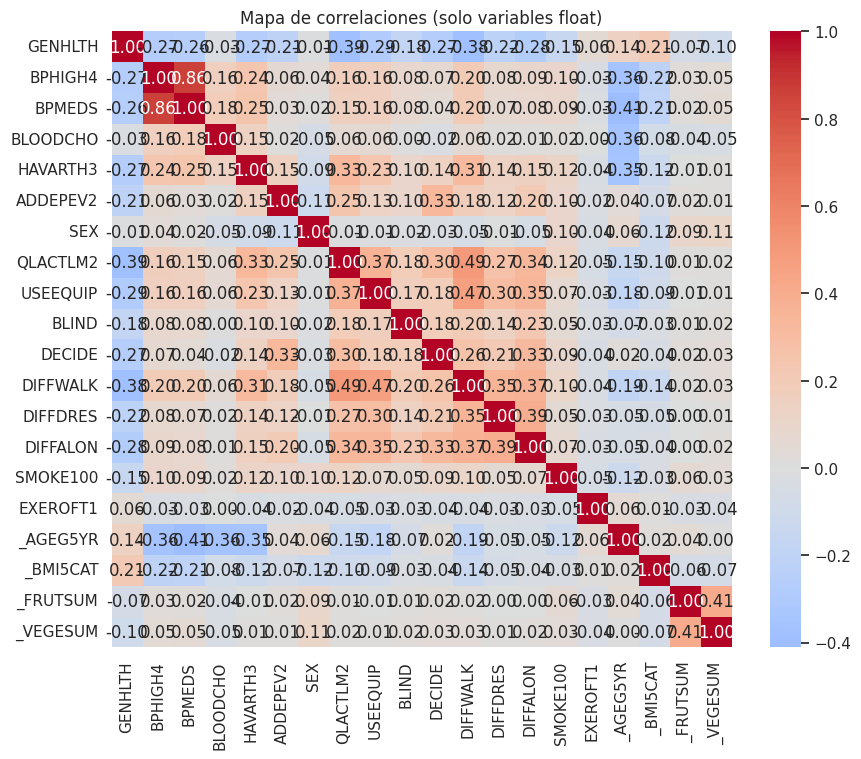

Tamaños -> Train: (154625, 26), Val: (51542, 26), Test: (51542, 26)
Pesos de clase: {np.int64(0): np.float64(0.561904934951668), np.int64(1): np.float64(4.538450249486352)}
scale_pos_weight para XGBoost: 0.123809869903336


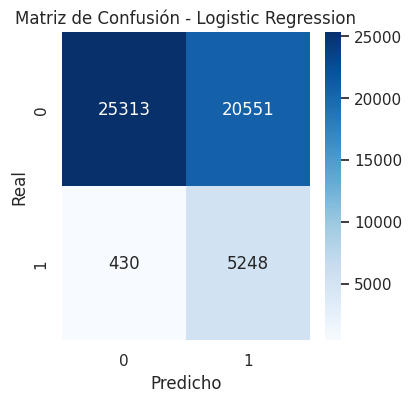

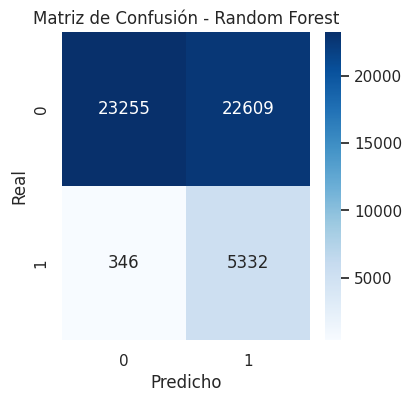

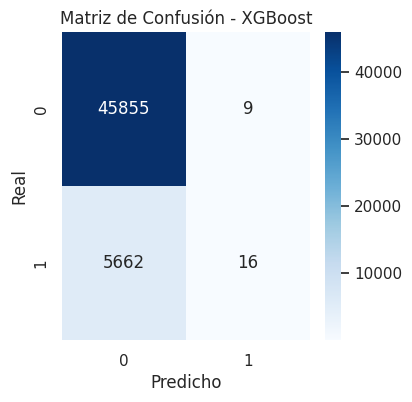


=== Comparativa de modelos (Validación, threshold=0.3) ===
                Modelo  Accuracy  Precision    Recall  F1-score   ROC-AUC
1        Random Forest  0.554635   0.190831  0.939063  0.317202  0.835219
0  Logistic Regression  0.592934   0.203419  0.924269  0.333450  0.838072
2              XGBoost  0.889973   0.640000  0.002818  0.005611  0.843827

Mejor modelo según Recall: Random Forest

=== Métricas en Test ===
{'Accuracy': 0.549745838345427, 'Precision': 0.1892131484699124, 'Recall': 0.9397675237759775, 'F1-score': 0.3150033944331297, 'ROC-AUC': np.float64(0.8311627756430378)}


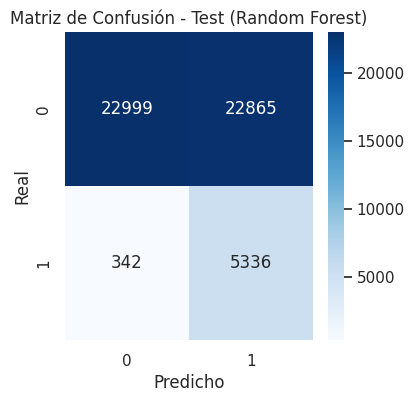

In [22]:
# Librerías
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# Se carga el dataset
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/10ª Edición Máster en Data Science/TFM/clean_data_v1.csv'
df = pd.read_csv(ruta,encoding='Latin-1')

print("Dimensiones:", df.shape)
print(df["DIABETE3"].value_counts(normalize=True))

# Se convierte a 0/1: 1 = diabético, 0 = no diabético
df['DIABETE3'] = df['DIABETE3'].map({1:1, 3:0})

# Análisis exploratorio de datos (EDA)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="DIABETE3", palette="Set2")
plt.title("Distribución de la variable objetivo (Diabetes)")
plt.xlabel("Diabetes (0 = No, 1 = Sí)")
plt.ylabel("Frecuencia")
plt.show()

numerical_cols = df.select_dtypes(include=['float']).columns #Para el mapa de correlaciones (solo numéricas, string dan errores)
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Mapa de correlaciones (solo variables float)")
plt.show()

# División de datos
X = df.drop("DIABETE3", axis=1)
y = df["DIABETE3"]

# X_temp -> temporal, luego se dividirá en validation y test. 60% entrenamiento / 40% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# X_temp se divide en 50/50 validación/test -> 20/20 del total del dataset
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Tamaños -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Escalado de las columnas numéricas: EXEROFT1 y sus variantes no se usarán en esta primera prueba!
categorical_nominal = ['_RACE', 'SEX', '_PACAT1']
categorical_ordinal = ['GENHLTH', '_BMI5CAT', '_AGEG5YR']
numerical = ['_FRUTSUM', '_VEGESUM'] + ['BPHIGH4','BPMEDS','BLOODCHO','HAVARTH3','QLACTLM2','USEEQUIP','BLIND','DECIDE', 'DIFFWALK','DIFFDRES','DIFFALON','SMOKE100','ADDEPEV2']

# Se hace la imputación para evitar problemas con la clase missing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())]), numerical),
        ("cat_nom", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_nominal),
        ("cat_ord", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ordinal", OrdinalEncoder())]), categorical_ordinal)
    ]
)

# Se calculan los pesos de clase, para posteriormente balancear. NO SE USA SMOTE para evitar datos sintéticos, generados no reales (mala praxis en cuestiones médicas)
classes = np.array([0, 1])  # clase positiva y negativa
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {k: v for k, v in zip(classes, weights)}
print("Pesos de clase:", class_weights)

# Para XGBoost
scale_pos_weight = class_weights[0] / class_weights[1]
print("scale_pos_weight para XGBoost:", scale_pos_weight)

# Entrenamiento de modelos
models = {
    "Logistic Regression": Pipeline([("preprocessor", preprocessor), ("classifier", LogisticRegression(max_iter=1000, class_weight=class_weights, solver='liblinear'))]), #Solver para la funcion de perdida
    "Random Forest": Pipeline([("preprocessor", preprocessor), ("classifier", RandomForestClassifier(n_estimators=300, max_depth=8, class_weight=class_weights, random_state=42))]),
    "XGBoost": Pipeline([("preprocessor", preprocessor), ("classifier", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1))])
}
    #scale_pos_weight: ajusta el balance entre clases factor multiplicativo que XGBoost aplica a los errores de la clase positiva en la función de pérdida

results = []
best_recall = 0
best_model_name = None
best_model_pipeline = None
# Ajustar umbral para maximizar recall (se baja de 0.5 a 0.3)
threshold = 0.3

for name, pipe in models.items():
    # Entrenar
    pipe.fit(X_train, y_train)

    # Obtener probabilidad de la clase positiva (1)
    y_prob = pipe.predict_proba(X_val)[:, 1]

    # Predicción con umbral
    y_pred = (y_prob >= threshold).astype(int)

    # Calcular métricas
    metrics = {
        "Modelo": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob)
    }
    results.append(metrics)

    # Matriz de confusión
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión - {name}")
    plt.show()

    # Selección del mejor modelo según Recall
    if metrics["Recall"] > best_recall:
        best_recall = metrics["Recall"]
        best_model_name = name
        best_model_pipeline = pipe

# Comparativa de modelos
results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)
print("\n=== Comparativa de modelos (Validación, threshold=0.3) ===")
print(results_df)
print(f"\nMejor modelo según Recall: {best_model_name}")

# Evaluación en test usando pipeline completo
y_prob_test = best_model_pipeline.predict_proba(X_test)[:,1]
y_pred_test = (y_prob_test >= threshold).astype(int)

# Métricas test
test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_test),
    "Precision": precision_score(y_test, y_pred_test),
    "Recall": recall_score(y_test, y_pred_test),
    "F1-score": f1_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score(y_test, y_prob_test)
}
print("\n=== Métricas en Test ===")
print(test_metrics)

# Matriz de confusión test
cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(4,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión - Test ({best_model_name})")
plt.show()
